In [36]:
import pandas as pd

In [37]:
data = pd.read_csv('main_df.csv', delimiter=',')

In [38]:
data

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,...,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
0,2024-01-01 00:00:00,район Кунцево,0,55.76,37.17,8,4,0,0,-11.00,...,0,0,1,I квартал,7,2,0,135092,0.32,289.40
1,2024-01-01 01:00:00,район Кунцево,0,55.76,37.17,11,11,1,1,-11.00,...,0,0,1,I квартал,7,2,0,135092,0.32,289.40
2,2024-01-01 02:00:00,район Кунцево,0,55.76,37.17,7,7,0,0,-11.00,...,0,0,1,I квартал,7,2,0,135092,0.32,289.40
3,2024-01-01 03:00:00,район Кунцево,0,55.76,37.17,12,8,0,0,-11.00,...,0,0,1,I квартал,7,2,0,135092,0.32,289.40
4,2024-01-01 04:00:00,район Кунцево,0,55.76,37.17,5,6,0,0,-11.00,...,0,0,1,I квартал,7,2,0,135092,0.32,289.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1229755,2024-12-31 19:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.40,...,2,0,1,IV квартал,16,5,300,110726,0.82,322.70
1229756,2024-12-31 20:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.60,...,0,0,1,IV квартал,16,5,300,110726,0.82,322.70
1229757,2024-12-31 21:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.50,...,0,0,1,IV квартал,6,5,300,110726,0.82,322.70
1229758,2024-12-31 22:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.80,...,0,0,1,IV квартал,6,5,300,110726,0.82,322.70


In [39]:
data.columns

Index(['timestamp', 'district_name', 'district_id', 'lat', 'lon',
       'n_taxi_start', 'n_taxi_end', 'n_carsharing_start', 'n_carsharing_end',
       'temperature', 'precipitation', 'humidity', 'wind_speed',
       'weather_code', 'rush_hour', 'season', 'is_holiday_or_weekend',
       'quarter', 'station_load', 'number_of_stations', 'number_of_places',
       'population_district_2023', 'population_near_metro', 'price_m2'],
      dtype='object')

**Описание данных:**

- Количественные признаки:
 - Непрерывные: lat, lon, temperature, precipitation, humidity, wind_speed, station_load, price_m2,population_near_metro
 - Дискретные: n_taxi_start, n_taxi_end, n_carsharing_start, n_carsharing_end, number_of_stations, number_of_places, population_district_2023
- Категориальные:
  - Бинарные: rush_hour, is_holiday_or_weekend
  - Порядковые: season, quarter
  - Номинальные: district_name, district_id, weather_code

Задание 1:
Есть ли пропуски в данных? Какой процент они составляют от числа строк? Почему они могли появиться? Если есть пропуски, выберите способ обработки пропусков для каждого столбца. Расскажите, почему выбрали именно этот способ. Обработайте пропуски.

In [40]:
data.isnull().sum()

,0
timestamp,0
district_name,0
district_id,0
lat,0
lon,0
n_taxi_start,0
n_taxi_end,0
n_carsharing_start,0
n_carsharing_end,0
temperature,0


По поводу пропусков в данных: они были обработаны еще на моменте парсинга данных, в датасете с которым работала я(загруженость метро, в ключевых колонках не было пропущенных значений)

In [41]:
passazhiro_potok = 'https://raw.githubusercontent.com/RuslanDavletov/Analysis-of-taxi-demand/refs/heads/main/data/passazhiro_potok.csv'

In [42]:
df = pd.read_csv(passazhiro_potok, delimiter=';')

In [43]:
df.isnull().sum()

,0
NameOfStation,0
Line,0
Year,0
Quarter,0
IncomingPassengers,0
OutgoingPassengers,0
global_id,0
Unnamed: 7,4621


Задание 2: Соответствуют ли типы данных в датасете тем, которые нужны (например, есть ли возраст в формате строки)? Исправьте это, если да.


In [44]:
data.dtypes

,0
timestamp,object
district_name,object
district_id,int64
lat,float64
lon,float64
n_taxi_start,int64
n_taxi_end,int64
n_carsharing_start,int64
n_carsharing_end,int64
temperature,float64


Все соотвествует, кроме временного признака timestamp. Для дальнейшей работы с датой приведем ее к надлежащему виду

In [45]:
data['timestamp'] = pd.to_datetime(data['timestamp'])

In [46]:
data.dtypes

,0
timestamp,datetime64[ns]
district_name,object
district_id,int64
lat,float64
lon,float64
n_taxi_start,int64
n_taxi_end,int64
n_carsharing_start,int64
n_carsharing_end,int64
temperature,float64


Задание 3: Посчитайте описательные статистики по всем переменным. + Задание 4:

Изучите каждый признак. Какие значения он принимает?
для числовых признаков - диапазон значений

для категориальных - уникальные значения


In [47]:
pd.set_option('display.float_format', '{:.2f}'.format)

data.describe()

,timestamp,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,precipitation,...,weather_code,rush_hour,season,is_holiday_or_weekend,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
count,1229760,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,...,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00,1229760.00
mean,2024-07-01 23:29:59.999998208,69.50,55.75,37.56,253.42,252.37,31.36,31.34,7.85,0.07,...,4.32,0.38,1.50,0.33,5.83,1.92,76.62,92540.39,0.41,267.92
min,2024-01-01 00:00:00,0.00,55.27,36.96,0.00,0.00,0.00,0.00,-31.40,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,9113.00,0.00,158.50
25%,2024-04-01 11:45:00,34.75,55.67,37.47,81.00,85.00,9.00,9.00,-0.30,0.00,...,2.00,0.00,1.00,0.00,0.00,0.00,19.00,65338.75,0.23,227.40
50%,2024-07-01 23:30:00,69.50,55.76,37.59,199.00,198.00,26.00,26.00,7.50,0.00,...,3.00,0.00,1.50,0.00,4.00,2.00,34.00,95660.00,0.42,251.35
75%,2024-10-01 11:15:00,104.25,55.83,37.69,338.00,324.00,46.00,45.00,17.50,0.00,...,4.00,0.25,2.00,1.00,8.00,3.00,83.50,116960.25,0.61,289.32
max,2024-12-31 23:00:00,139.00,56.00,37.94,19606.00,23266.00,674.00,854.00,35.00,11.90,...,25.00,2.00,3.00,1.00,62.00,14.00,300.00,255044.00,1.00,518.40
std,NaN,40.41,0.12,0.19,259.75,269.08,28.21,28.20,11.33,0.38,...,4.52,0.70,1.12,0.47,6.64,1.98,93.72,45148.86,0.28,64.85


In [48]:
data['humidity'].describe()

,humidity
count,1229760.00
mean,73.27
std,17.38
min,20.00
25%,61.00
50%,77.00
75%,87.00
max,100.00


In [49]:
data['wind_speed'].describe()

,wind_speed
count,1229760.00
mean,7.31
std,6.65
min,0.00
25%,3.60
50%,5.50
75%,10.80
max,47.00


Посмторим на каждую колонку(некоторые колонки по типу категориальных я посмотрю чуть ниже) и полученные результаты:
Про вреенной признак timestamp	даже не имеет смысл говорить, данные распределены равномерно(25-й перцинтиль - 1 апреля, медиана - 1 июля, 75-й перцинтиль - 1 октября)

lat и lon, пропустим, поскольку это координаты, перейдем сразу к поездкам на такси и каршеринге


n_taxi_start и n_taxi_end: диапазон значений от 0 до 19606(для начала) и до 23266(для конца), а вот среднее 253(для начала) и 252(для конца), вероятнее всего тут есть выбросы, данные слишком сильно варьируются

n_carsharing_start и n_carsharing_end: диапазон значений от 0 до 674(для начала) и до 854(для конца), среднее 31(для начала) и 31(для конца),ну тут все уже вроде лучше, но заметна большая разница между спросом на такси и на каршеринг(на каршеринг сильно меньше)

На температуру смотреть не буду, посмотрим на precipitation - диапазон значений о 0 до 11, но можно заметить, что большинтсво дней были без осадков, тк 50-й перцинтиль - 0 и 75-й  - 0

humidity - диапазон от 20 до 100, в среднем влажность воздуха была около 73

wind_speed - диапазон от 0 до 47, в среднем около 7

посмотрю на station_load - диапазон значений от 0 до 62(разбалловка зависит от многих факторов, по типу праздник ли, если нет, то значение больше, если час пик то значение еще больше итп)

number_of_places - от 0 до 300, количество месть доступных в районе, в среднем около 76

number_of_stations - от 0 до 14, в среднем около 2 станций входит в район

population_district_2023 - от 9 113 до 255 044 в среднем около 92 тыс, население районов сильно варьируется

population_near_metro - от 0 до 1, в среднем около 0.41 - доля населения людей живущих рядом с метро

price_m2 - от 158 до 518, включает в себя различные жк, поэтому стоимость сильно варьируется

Теперь посмотрим на категориальные данные и их уникальные значения

In [50]:
data['district_name'].unique() #уникальные названия районов

array(['район Кунцево', 'район Крылатское', 'Мещанский район',
       'район Сокольники', 'район Коммунарка', 'Филимонковский район',
       'район Внуково', 'район Хорошёво-Мнёвники', 'район Щукино',
       'район Строгино', 'район Митино', 'район Куркино',
       'район Кузьминки', 'Донской район', 'район Левобережный',
       'район Ховрино', 'район Западное Дегунино', 'Тимирязевский район',
       'район Коптево', 'Дмитровский район', 'район Северное Тушино',
       'район Сокол', 'Савёловский район', 'район Отрадное',
       'Молжаниновский район', 'район Северный',
       'район Восточное Дегунино', 'Головинский район', 'район Беговой',
       'Хорошёвский район', 'Войковский район', 'район Аэропорт',
       'район Южное Тушино', 'район Покровское-Стрешнево',
       'Бескудниковский район', 'Алтуфьевский район', 'район Лианозово',
       'район Бибирево', 'район Северное Медведково',
       'район Южное Медведково', 'район Фили-Давыдково',
       'район Филёвский Парк', 'район До

In [51]:
data['weather_code'].unique() #уникальные значения кода погоды

array([ 3,  5,  2,  1, 14, 15, 16, 12, 21,  8,  7, 17,  9, 13, 19, 18,  4,
       25, 10, 22])

| Код | Погодное условие         |
|-----|--------------------------|
| 1   | Ясно                    |
| 2   | Солнечно                 |
| 3   | Облачно                  |
| 4   | Пасмурно                 |
| 5   | Туман                    |
| 6   | Ледяной туман            |
| 7   | Легкий дождь             |
| 8   | Дождь                    |
| 9   | Сильный дождь            |
| 10  | Ледяной дождь            |
| 11  | Сильный ледяной дождь    |
| 12  | Дождь со снегом          |
| 13  | Сильный дождь со снегом  |
| 14  | Легкий снегопад          |
| 15  | Снегопад                 |
| 16  | Сильный снегопад         |
| 17  | Дождевой ливень          |
| 18  | Сильный дождевой ливень  |
| 19  | Дождь со снегом (ливень) |
| 20  | Сильный дождь со снегом  |
| 21  | Снежный ливень           |
| 22  | Сильный снежный ливень   |
| 23  | Молния                   |
| 24  | Град                     |
| 25  | Гроза                    |

In [52]:
data['is_holiday_or_weekend'].unique() #уникальыне значения является ли день праздником или нет

array([1, 0])

In [53]:
data['rush_hour'].unique() #час пик

array([0, 1, 2])

In [54]:
data['season'].unique() #сезон

array([0, 1, 2, 3])

| Код | Сезон         |
|-----|--------------------------|
| 0   | Зима                     |
| 1   | Весна                    |
| 2   | Лето                     |
| 3   | Осень                    |

In [55]:
data['district_id'].unique() #уникальные id района Москвы

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139])

Есть ли в данных выбросы или ошибки (например, отрицательная цена)? Как вы их определяете? Обработайте выбросы.


Посмотрю на часть с загруженностью метро, за которую я отвечала

<Axes: ylabel='station_load'>

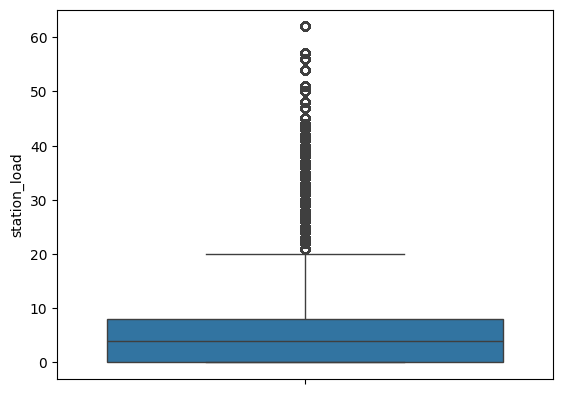

In [56]:
import seaborn as sns
sns.boxplot(data['station_load'])

Теперь посмотрим сколько их и буду думать что делать дальше

In [57]:
Q1 = data['station_load'].quantile(0.25)
Q3 = data['station_load'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['station_load'] < lower_bound) | (data['station_load'] > upper_bound)]
outliers

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,...,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
52903,2024-01-09 07:00:00,Мещанский район,6,55.78,37.63,234,399,37,59,-8.90,...,1,0,0,I квартал,22,6,300,56001,0.96,403.70
52904,2024-01-09 08:00:00,Мещанский район,6,55.78,37.63,410,521,61,80,-8.60,...,1,0,0,I квартал,22,6,300,56001,0.96,403.70
52905,2024-01-09 09:00:00,Мещанский район,6,55.78,37.63,584,822,51,72,-8.40,...,1,0,0,I квартал,22,6,300,56001,0.96,403.70
52913,2024-01-09 17:00:00,Мещанский район,6,55.78,37.63,519,428,111,47,-6.60,...,2,0,0,I квартал,22,6,300,56001,0.96,403.70
52914,2024-01-09 18:00:00,Мещанский район,6,55.78,37.63,513,413,81,38,-6.90,...,2,0,0,I квартал,22,6,300,56001,0.96,403.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1229649,2024-12-27 09:00:00,Басманный район,139,55.77,37.67,1123,1693,80,123,1.70,...,1,0,0,IV квартал,22,5,300,110726,0.82,322.70
1229657,2024-12-27 17:00:00,Басманный район,139,55.77,37.67,1067,1120,114,110,1.00,...,2,0,0,IV квартал,22,5,300,110726,0.82,322.70
1229658,2024-12-27 18:00:00,Басманный район,139,55.77,37.67,1228,1416,116,101,0.80,...,2,0,0,IV квартал,22,5,300,110726,0.82,322.70
1229659,2024-12-27 19:00:00,Басманный район,139,55.77,37.67,1445,1561,130,86,0.70,...,2,0,0,IV квартал,22,5,300,110726,0.82,322.70


Вообще я бы не стала считать данные за выбросы поскольку такая загруженность метро связана со многими факторами, выходной ли это, есть ли час пик итп. Но в любом случае хочу нормализовать данные для дальнейшей работы с ними. Буду пользоваться минмакс нормализацией, как и в прошлый раз, когда предобрабатывала данные

In [71]:
from sklearn.preprocessing import MinMaxScaler

s = MinMaxScaler()
data['station_load_normalized'] = s.fit_transform(data[['station_load']])
data

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,...,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2,station_load_normalized,station_load_n
0,2024-01-01 00:00:00,район Кунцево,0,55.76,37.17,8,4,0,0,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
1,2024-01-01 01:00:00,район Кунцево,0,55.76,37.17,11,11,1,1,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
2,2024-01-01 02:00:00,район Кунцево,0,55.76,37.17,7,7,0,0,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
3,2024-01-01 03:00:00,район Кунцево,0,55.76,37.17,12,8,0,0,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
4,2024-01-01 04:00:00,район Кунцево,0,55.76,37.17,5,6,0,0,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1229755,2024-12-31 19:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.40,...,1,IV квартал,16,5,300,110726,0.82,322.70,0.26,3
1229756,2024-12-31 20:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.60,...,1,IV квартал,16,5,300,110726,0.82,322.70,0.26,3
1229757,2024-12-31 21:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.50,...,1,IV квартал,6,5,300,110726,0.82,322.70,0.10,1
1229758,2024-12-31 22:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.80,...,1,IV квартал,6,5,300,110726,0.82,322.70,0.10,1


Разбиваю на 10 примерно равных между собой участков с помощью pd.cut

In [72]:
data["station_load_n"] = pd.cut(data['station_load_normalized'], bins=10, labels=False) + 1
data

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,...,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2,station_load_normalized,station_load_n
0,2024-01-01 00:00:00,район Кунцево,0,55.76,37.17,8,4,0,0,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
1,2024-01-01 01:00:00,район Кунцево,0,55.76,37.17,11,11,1,1,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
2,2024-01-01 02:00:00,район Кунцево,0,55.76,37.17,7,7,0,0,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
3,2024-01-01 03:00:00,район Кунцево,0,55.76,37.17,12,8,0,0,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
4,2024-01-01 04:00:00,район Кунцево,0,55.76,37.17,5,6,0,0,-11.00,...,1,I квартал,7,2,0,135092,0.32,289.40,0.11,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1229755,2024-12-31 19:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.40,...,1,IV квартал,16,5,300,110726,0.82,322.70,0.26,3
1229756,2024-12-31 20:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.60,...,1,IV квартал,16,5,300,110726,0.82,322.70,0.26,3
1229757,2024-12-31 21:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.50,...,1,IV квартал,6,5,300,110726,0.82,322.70,0.10,1
1229758,2024-12-31 22:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.80,...,1,IV квартал,6,5,300,110726,0.82,322.70,0.10,1


In [73]:
data["station_load_n"].unique()

array([ 2,  4,  3,  1,  5,  8,  7,  6, 10,  9])

In [74]:
data['station_load'] = data["station_load_n"]

In [76]:
data.drop(columns=['station_load_normalized', 'station_load_n'])

,timestamp,district_name,district_id,lat,lon,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,temperature,...,rush_hour,season,is_holiday_or_weekend,quarter,station_load,number_of_stations,number_of_places,population_district_2023,population_near_metro,price_m2
0,2024-01-01 00:00:00,район Кунцево,0,55.76,37.17,8,4,0,0,-11.00,...,0,0,1,I квартал,2,2,0,135092,0.32,289.40
1,2024-01-01 01:00:00,район Кунцево,0,55.76,37.17,11,11,1,1,-11.00,...,0,0,1,I квартал,2,2,0,135092,0.32,289.40
2,2024-01-01 02:00:00,район Кунцево,0,55.76,37.17,7,7,0,0,-11.00,...,0,0,1,I квартал,2,2,0,135092,0.32,289.40
3,2024-01-01 03:00:00,район Кунцево,0,55.76,37.17,12,8,0,0,-11.00,...,0,0,1,I квартал,2,2,0,135092,0.32,289.40
4,2024-01-01 04:00:00,район Кунцево,0,55.76,37.17,5,6,0,0,-11.00,...,0,0,1,I квартал,2,2,0,135092,0.32,289.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1229755,2024-12-31 19:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.40,...,2,0,1,IV квартал,3,5,300,110726,0.82,322.70
1229756,2024-12-31 20:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.60,...,0,0,1,IV квартал,3,5,300,110726,0.82,322.70
1229757,2024-12-31 21:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.50,...,0,0,1,IV квартал,1,5,300,110726,0.82,322.70
1229758,2024-12-31 22:00:00,Басманный район,139,55.77,37.67,0,0,0,0,-1.80,...,0,0,1,IV квартал,1,5,300,110726,0.82,322.70


Постройте матрицу корреляций числовых переменных.

In [77]:
#все числовые переменные
numeric_columns = [
    'lat', 'lon', 'temperature', 'precipitation', 'humidity', 'wind_speed',
    'station_load', 'price_m2', 'population_near_metro',
    'n_taxi_start', 'n_taxi_end', 'n_carsharing_start', 'n_carsharing_end',
    'number_of_stations', 'number_of_places', 'population_district_2023'
]

Для построения использую [хитмапу](https://seaborn.pydata.org/generated/seaborn.heatmap.html) из библиотеки sns

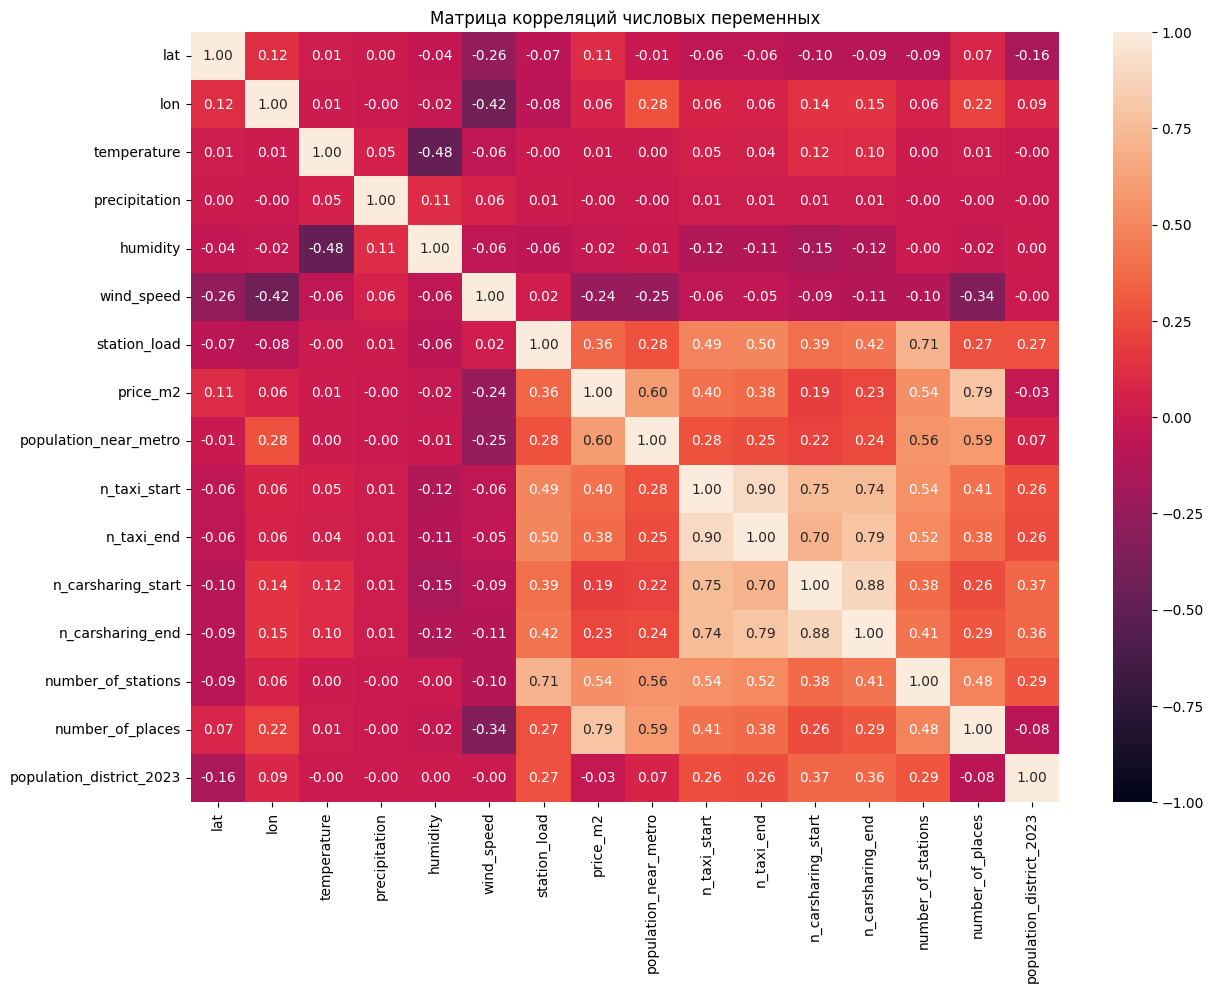

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(data[numeric_columns].corr(), annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('Матрица корреляций числовых переменных')
plt.show()

Исходя из этого графика можно заметить следующие зависимости:

1) Цена за квадратный метр(price_m2) сильно коллерирует с колонкой population_near_metro(0.6), что дает возможность сказать, что стоимость квадратного метра повышается в местах, находящихся рядом с метро, то же самое можно сказать и про колонку отвечающую за количество культурных мест в районе, стоимость квадратного метра сильно увеличивается в "популярных" районах.

2) Загруженность станции(station_load) сильно кореллирует с количеством станций в районе(number_of_stations), что вполне логично, поскольку чем больше станций в районе тем большая загруженность(и популярность места). Также можно заметить высокую корелляцию с количеством начала и окончания поездок на такси(это указывает на то что люди в основном доезжают до метро на такси или наоборот в местах где станции загруженны).

3) Процент людей проживающих рядом с метро сильно кореллирует с количеством станций входящих в район, что логично, тк большое количество станций на районе привлекает большее количество людей. Аналогично насчет связи с колчество культурных мест(number_of_places) чем больше таких мест, тем больше спрос на жилье в данном районе и соотвественно больший процент людей.

4) Также можно заметить сильную связь(0.79) между количеством окончаний поездок и их началом, что указывает на то, что большинство поезок были совершены в одном районе. И еще можно заметить достаточно сильную корелляцию между количеством поездок на такси и каршеринге(что про начало поездок, что про окончание), можно сделать вывод, что такси и каршеринг часто используют в одних и тех же районах

In [106]:
numeric_columns = [
    'lat', 'lon', 'temperature', 'precipitation', 'humidity', 'wind_speed', 'price_m2', 'population_near_metro',
    'n_taxi_start', 'n_taxi_end', 'n_carsharing_start', 'n_carsharing_end', 'number_of_places', 'population_district_2023'
]

Постройте гистограммы распределения числовых переменных, посмотрю на распределение основных переменных(типа загруженности метро, )


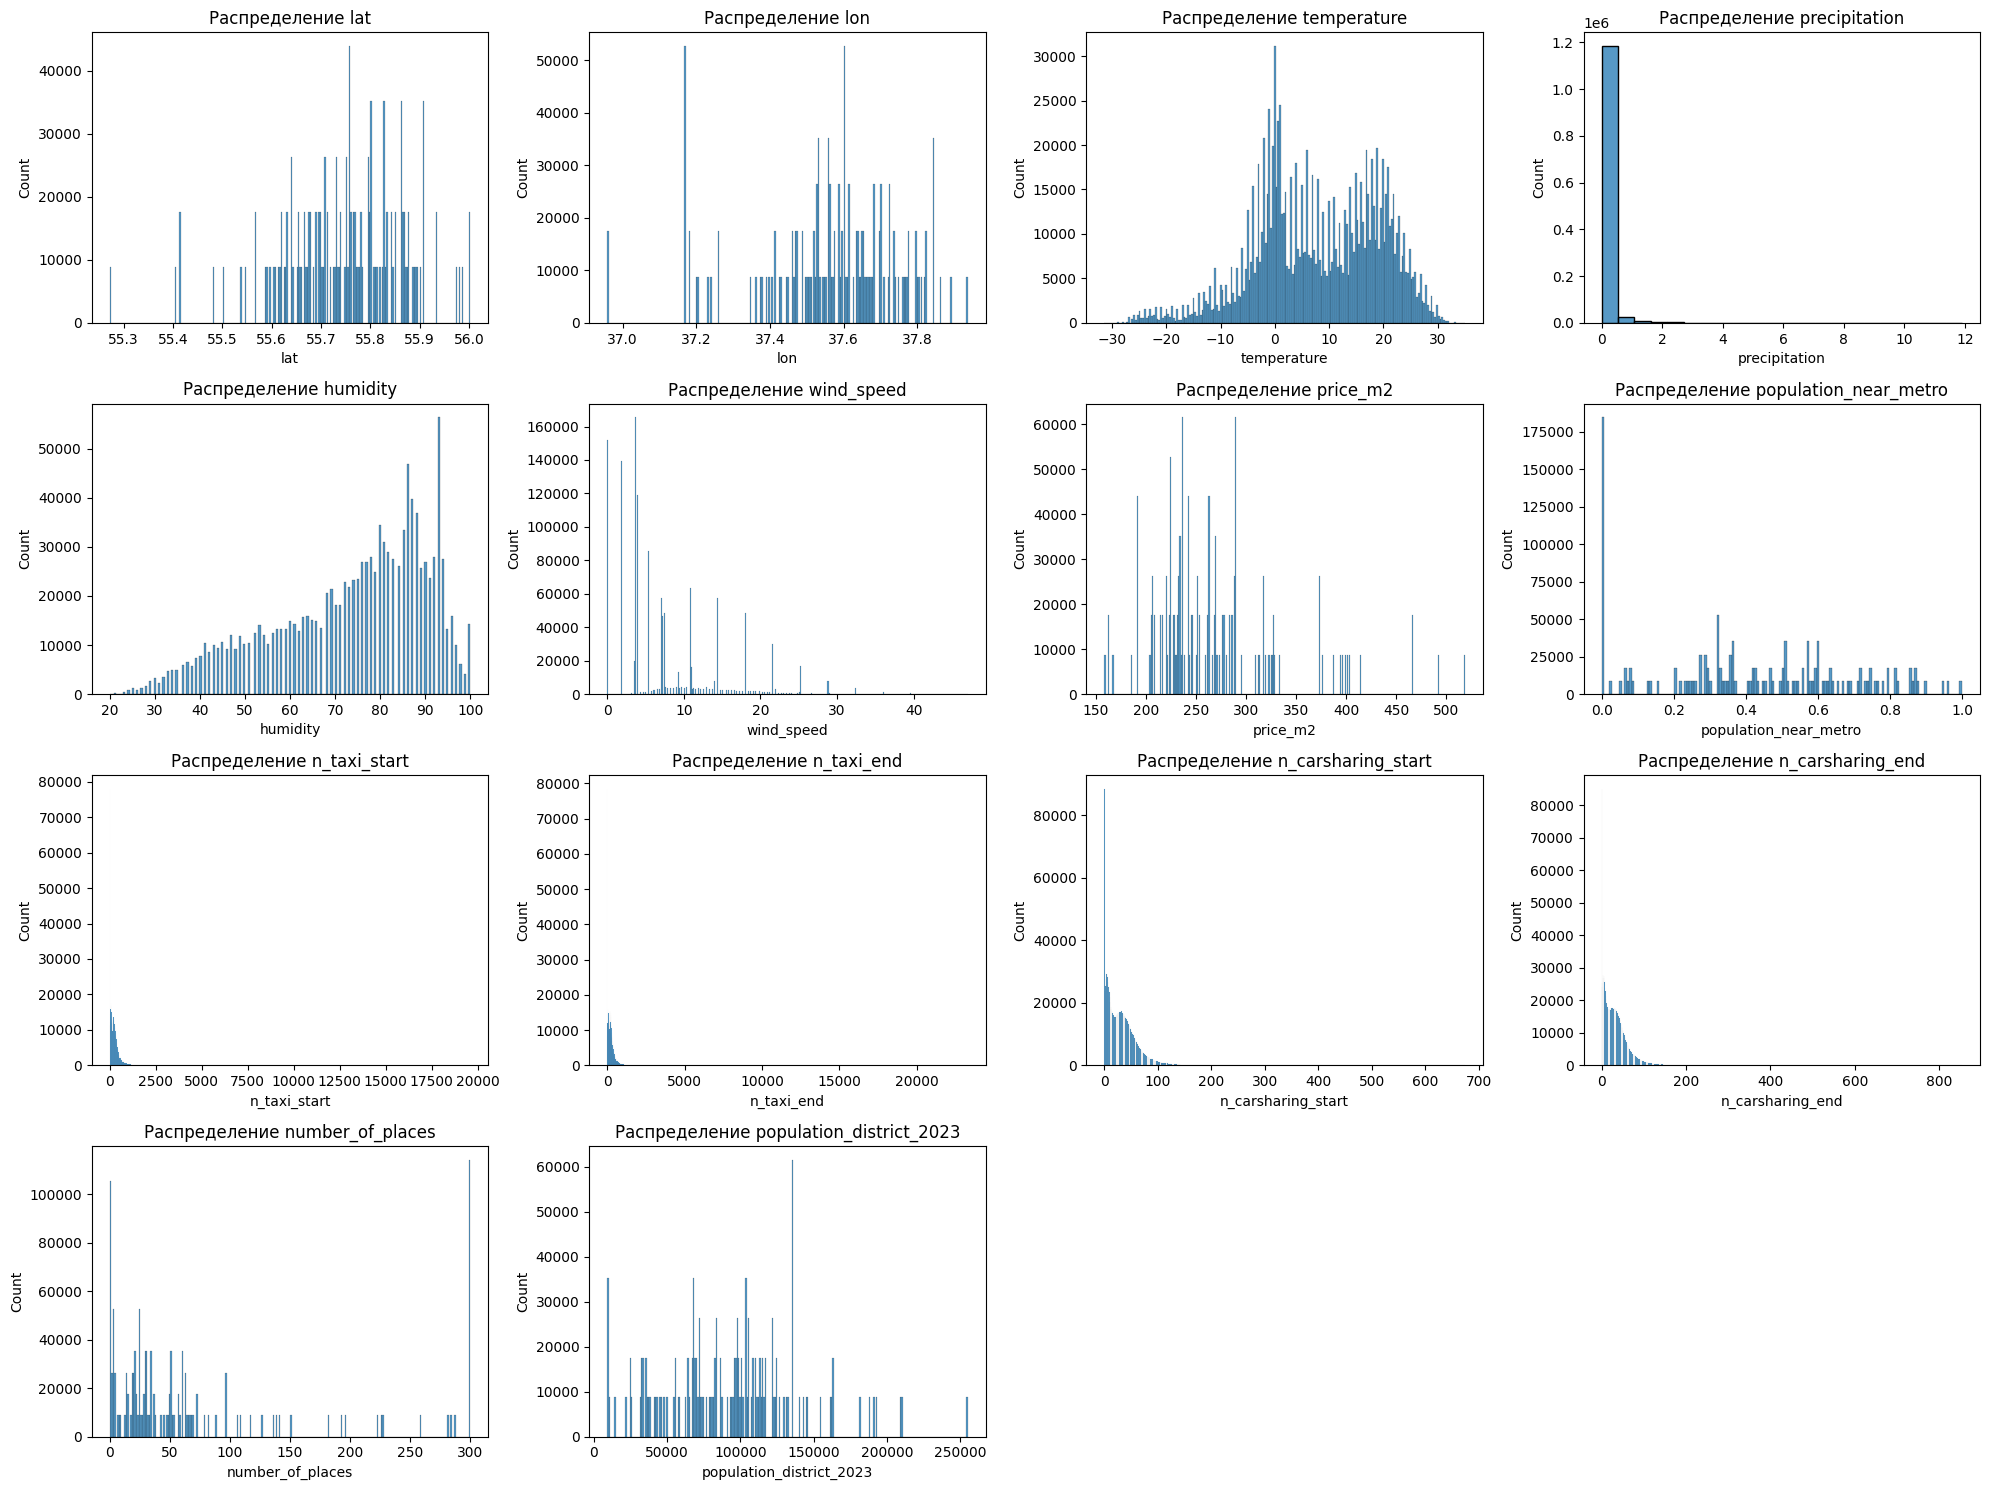

In [107]:
import numpy as np
plt.figure(figsize=(20, 15))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(data[column])
    plt.title(f'Распределение {column}')
plt.tight_layout()
plt.show()

In [100]:
data['number_of_stations'].value_counts()

,count
number_of_stations,
0,320592
2,285504
1,281088
3,114192
4,114192
5,61488
6,35136
8,8784
14,8784


Для категориальных переменных постройте столбчатые диаграммы


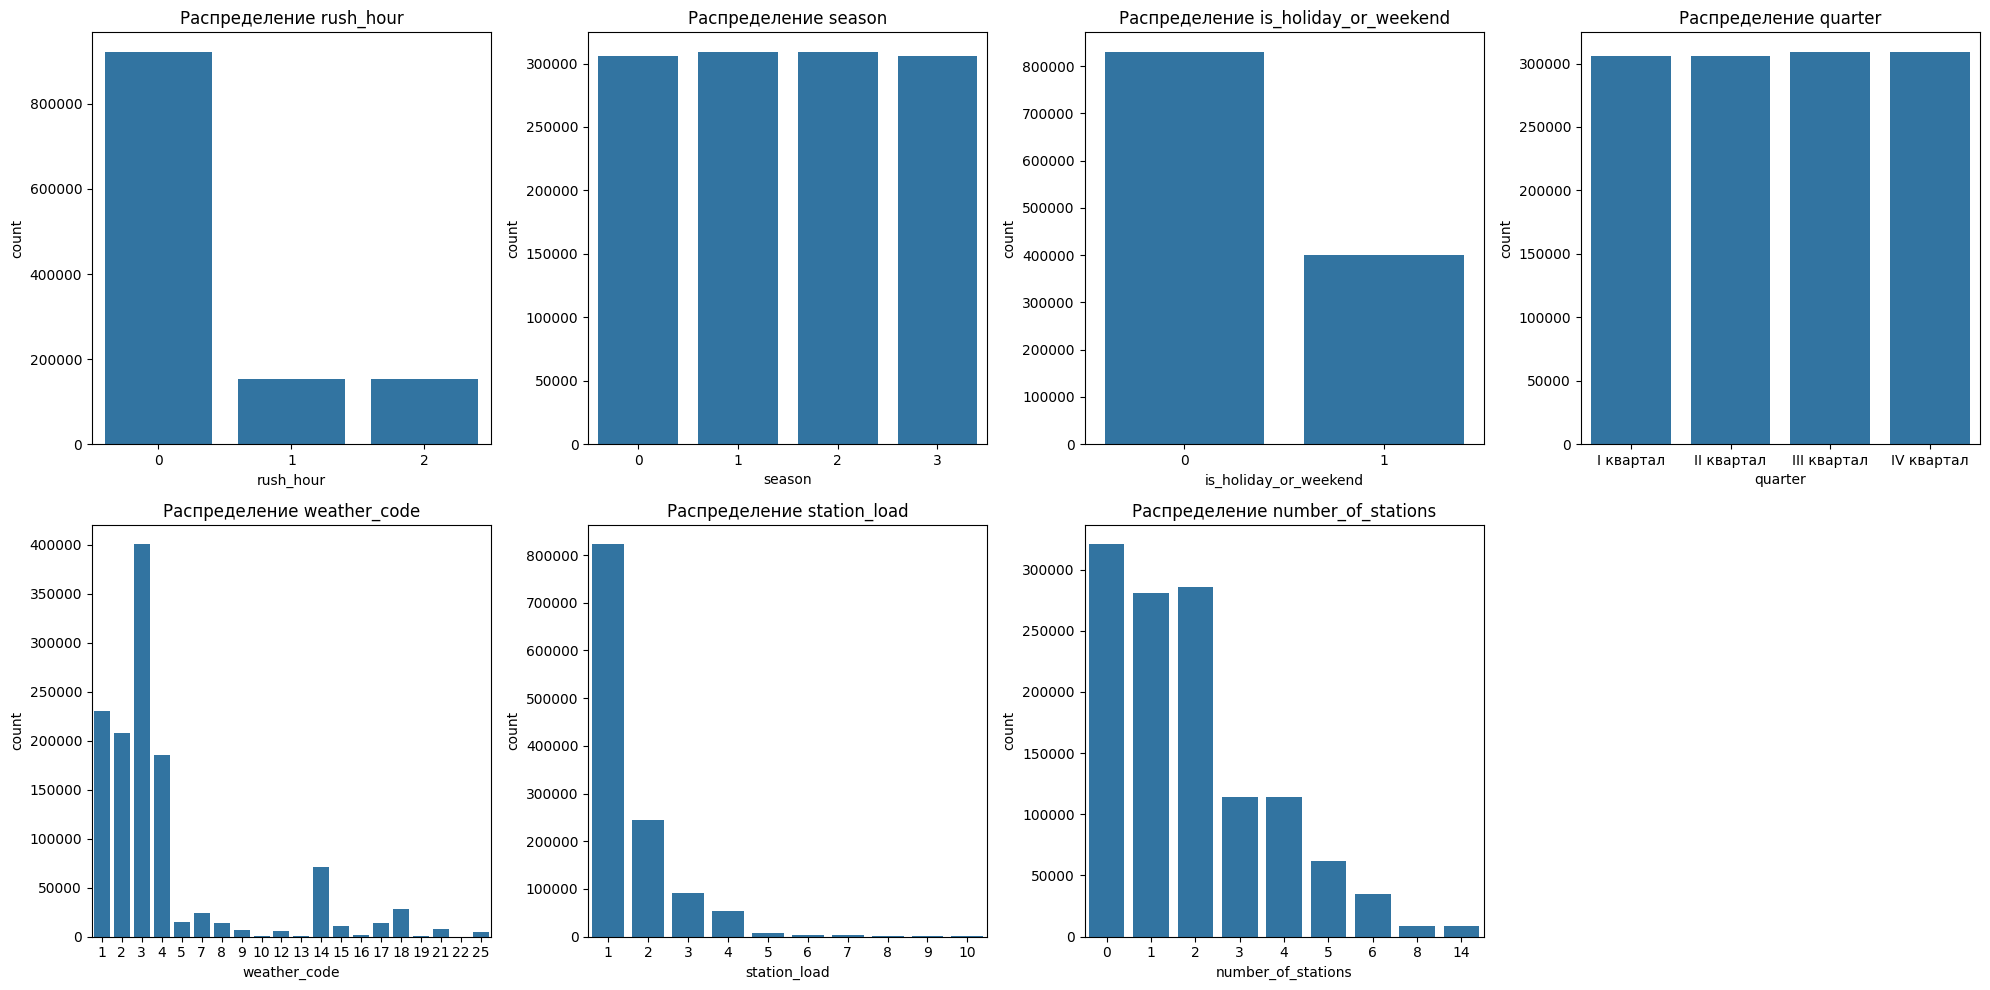

In [104]:
categorical_columns = [
    'rush_hour', 'season', 'is_holiday_or_weekend', 'quarter', 'weather_code', "station_load", "number_of_stations"
]

plt.figure(figsize=(20, 10))
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(2, 4, i)
    sns.countplot(data=data, x = column)
    plt.title(f'Распределение {column}')
plt.tight_layout()
plt.show()